# PBMRS Demo Notebook

This notebook prints numeric values from a short PBMRS-style simulation and plots the resulting series.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root / "src"))

from pbmrs_core import SimConfig, run_sim


In [2]:
# Run a full PBMRS simulation directly inside the notebook.
cfg = SimConfig(seed=7, timesteps=200, n_agents=300, q0=0.008)
result = run_sim(cfg)

prices = result.prices
returns = result.r
volatility = result.v
liquidity = result.l

print("Simulation configuration:")
print(f"  seed={cfg.seed}")
print(f"  timesteps={cfg.timesteps}")
print(f"  n_agents={cfg.n_agents}")
print(f"  q0={cfg.q0}")
print()
print("Summary metrics:")
print(f"  final_price={prices[-1]:.6f}")
print(f"  max_drawdown={np.max(1.0 - prices / np.maximum.accumulate(prices)):0.6f}")
print(f"  mean_return={np.mean(returns):.6f}")
print(f"  return_std={np.std(returns):.6f}")
print(f"  min_liquidity={np.min(liquidity):.6f}")
print(f"  max_volatility={np.max(volatility):.6f}")
print()
print("First 10 price values:")
print(prices[:10])
print("\nFirst 10 return values:")
print(returns[:10])
print("\nFirst 10 volatility values:")
print(volatility[:10])
print("\nFirst 10 liquidity values:")
print(liquidity[:10])


Simulation configuration:
  seed=7
  timesteps=200
  n_agents=300
  q0=0.008

Summary metrics:
  final_price=1.094344
  max_drawdown=0.245170
  mean_return=0.000451
  return_std=0.012307
  min_liquidity=0.928743
  max_volatility=1.009151

First 10 price values:
[1.         1.00897327 1.0176559  1.0222764  1.04395252 1.0450957
 1.05684445 1.06522155 1.06669342 1.04705354]

First 10 return values:
[ 0.00893325  0.0085686   0.00453006  0.0209821   0.00109445  0.01117907
  0.00789527  0.0013808  -0.01858354  0.00625261]

First 10 volatility values:
[1.         1.00033672 1.00052452 1.00062462 1.00176982 1.00168457
 1.00192879 1.00196534 1.00188869 1.0024078 ]

First 10 liquidity values:
[1.         0.99736    0.9955091  0.99394809 0.98955091 0.98957129
 0.98743361 0.98631274 0.9859444  0.9834294 ]


<string>:30: UserWarning: q0 * n_agents = 2.400 is outside [0.5, 2.0]


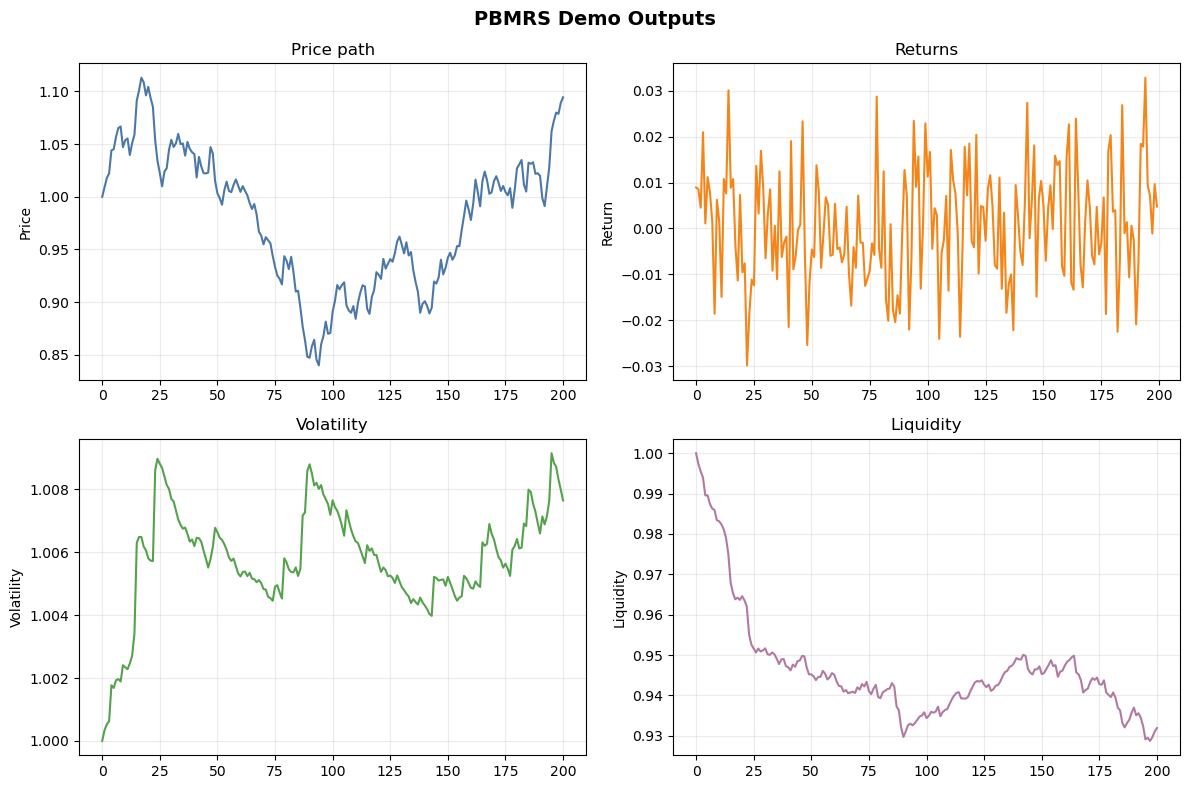

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("PBMRS Demo Outputs", fontsize=14, fontweight="bold")

axs[0, 0].plot(prices, color="#4C78A8")
axs[0, 0].set_title("Price path")
axs[0, 0].set_ylabel("Price")

axs[0, 1].plot(returns, color="#F58518")
axs[0, 1].set_title("Returns")
axs[0, 1].set_ylabel("Return")

axs[1, 0].plot(volatility, color="#54A24B")
axs[1, 0].set_title("Volatility")
axs[1, 0].set_ylabel("Volatility")

axs[1, 1].plot(liquidity, color="#B279A2")
axs[1, 1].set_title("Liquidity")
axs[1, 1].set_ylabel("Liquidity")

for ax in axs.flat:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [4]:
output_path = Path("results") / "pbmrs_demo_notebook_values.txt"
output_path.parent.mkdir(exist_ok=True)

with output_path.open("w", encoding="utf-8") as handle:
    handle.write("Price path values\n")
    handle.write("\n".join(map(str, prices)) + "\n")
    handle.write("\nReturn values\n")
    handle.write("\n".join(map(str, returns)) + "\n")

print(f"Saved numeric values to {output_path}")


Saved numeric values to results\pbmrs_demo_notebook_values.txt
